## VGG-19 Implementation

#### This project implements VGG19 from scratch in PyTorch. During initial experimental runs, optimization was noticeably slower and less stable. To improve training dynamics, Batch Normalization layers were added after each convolutional layer, resulting in a VGG19-BN variant used for the final experiments.

---

##### Architecture Diagram

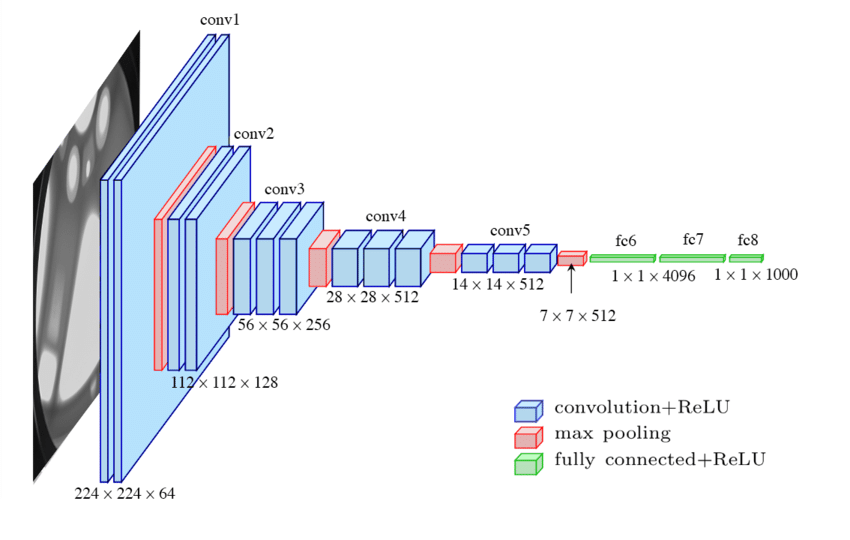

---

### Plan

Since I want the architecture implementation to be modular and easily swappable, I also want to keep the code structure consistent with the original VGG-19 design.
As shown in the architecture diagram and configuration table, VGG-19 is built by stacking convolution layers followed by a max-pooling layer. The first two stages contain 2 convolution layers + max pooling, while the later stages contain 4 convolution layers + max pooling.
To avoid repeating the same code and to keep the implementation clean, I plan to create a reusable block that accepts the number of convolution layers as a parameter and automatically builds:
Conv2D → ReLU → Conv2D → ReLU → ... → MaxPool
This way, each VGG stage can be created by simply specifying how many convolution layers it should contain

---

#### Configurations

In [1]:
config = {
    # ------------------------------- ConvNets Configurations -------------------------------
    "conv_kernel_size": 3,
    "conv_stride": 1,
    "padding": 1,
    "max_pool_stride": 2,
    "max_pool_kernel_size": 2,
    "hidden_channel_layer_1": 64,
    # ------------------------------- Fully Connected Layer Configurations -------------------------------
    "fc_in_features": 25088, # Output tensor of 16 ConvNets  = [B, 512, 7, 7] | flattening = 512 * 7 * 7 = 25088
    "fc_hidden_dim": 4096, 
    "n_classes": 200,

    # ------------------------------- VGG-19 Model Specific Configurations -------------------------------
    "in_channels": 3,
    "optimizer": "SGD", # (According to Original VGG-19 Paper)
    "weight_decay": 5e-4,
    "lr": 0.001,
    "momentum": 0.9,
    "batch_size": 24,
    "epochs": 200, # I have early Stopping configured

    # ------------------------------ Image Configurations -------------------------------
    "img_size": 224,
}

---

### VGGBlock

In [2]:
import torch
import torch.nn as nn

In [3]:
class VGGBlock(nn.Module):
    """
    Implements a reusable VGG building block.

    I wanted the VGG implementation to be modular so that different
    VGG variants can be created without repeating code. After studying
    the original architecture, I noticed that each stage follows the
    same pattern:

        Conv2D -> ReLU -> ... -> MaxPool

    The only thing that changes between stages is the number of
    convolution layers. This block abstracts that pattern and allows
    a stage to be created by simply specifying the number of
    convolution layers required.

    This keeps the implementation cleaner, easier to maintain,
    and closer to the design of the original paper.

    Paper:
    Very Deep Convolutional Networks for Large-Scale Image Recognition
    https://arxiv.org/pdf/1409.1556
    """
    def __init__(self,
                in_channels: int,
                hidden_channels: int,
                conv_kernel_size: int = config["conv_kernel_size"],
                conv_stride: int = config["conv_stride"],
                padding: int = config["padding"],
                debug: bool = False):
                
                super(VGGBlock, self).__init__()

                self.debug = debug

                self.conv_1 = nn.Conv2d(
                    in_channels = in_channels,
                    out_channels = hidden_channels,
                    kernel_size = conv_kernel_size,
                    stride = conv_stride,
                    padding = padding
                )
                self.batch_norm_1 = nn.BatchNorm2d(hidden_channels)
                self.batch_norm_2 = nn.BatchNorm2d(hidden_channels)

                self.relu = nn.ReLU()

                self.conv_2 = nn.Conv2d(
                    in_channels = hidden_channels,
                    out_channels = hidden_channels,
                    kernel_size = conv_kernel_size,
                    stride = conv_stride,
                    padding = padding
                )

                # self.block = nn.Sequential(
                #     self.conv_1, self.relu, self.conv_2, self.relu
                # )
                self.block = nn.Sequential(
                    self.conv_1, self.batch_norm_1, self.relu, self.conv_2, self.batch_norm_2, self.relu
                )
    
    def forward(self, x: torch.Tensor):
        if self.debug:
            for i, layer in enumerate(self.block):
                x = layer(x)
                print(f"Layer {i:02d} ({layer.__class__.__name__}): {x.shape}")
            return x

        return self.block(x)
            

---

#### MaxPool Class

In [4]:
class MaxPool2d(nn.Module):
    """
    This class implements the max-pooling operation used throughout the
    VGG-19 architecture.

    Max pooling reduces the spatial resolution of feature maps while
    preserving the most dominant activations within each local region.
    This operation increases the receptive field of subsequent layers
    and improves computational efficiency by progressively downsampling
    the feature representations.

    Paper:
    Very Deep Convolutional Networks for Large-Scale Image Recognition

    Link:
    https://arxiv.org/pdf/1409.1556
    """
    def __init__(self,
            max_pool_stride: int = config["max_pool_stride"],
            max_pool_kernel_size: int = config["max_pool_kernel_size"]):
        
        super(MaxPool2d, self).__init__()
        
        self.max_pool_stride = max_pool_stride
        self.max_pool_kernel_size = max_pool_kernel_size

        self.max_pool2d = nn.MaxPool2d(
            kernel_size = self.max_pool_kernel_size,
            stride = self.max_pool_stride
        )
    
    def forward(self, x: torch.Tensor):
        return self.max_pool2d(x)

### ConvNets: Stacking VGGBocks

In [5]:
class ConvNets(nn.Module):
    """
    This class implements the convolutional feature extraction backbone of
    the VGG-19 architecture.

    The backbone is composed of stacked VGG blocks and max-pooling layers
    that progressively transform the input image into high-level feature
    representations. Spatial resolution is reduced through pooling while
    the number of feature channels is increased, enabling hierarchical
    feature learning across multiple scales.

    Paper:
    Very Deep Convolutional Networks for Large-Scale Image Recognition

    Link:
    https://arxiv.org/pdf/1409.1556
    """
    def __init__(self,
                in_channels: int,
                conv_kernel_size: int = config["conv_kernel_size"],
                conv_stride: int = config["conv_stride"],
                padding: int = config["padding"],
                max_pool_stride: int = config["max_pool_stride"],
                max_pool_kernel_size: int = config["max_pool_kernel_size"],
                debug: bool = False):
        super(ConvNets, self).__init__()
        self.in_channels = in_channels
        prev_channels = config["hidden_channel_layer_1"]

        # Inserting 1st Layer (3 channel -> 64 channels) + MaxPool [2 ConvNets + ReLU]
        self.vgg_19_blocks = [
            nn.Sequential(VGGBlock(
                    in_channels = self.in_channels,
                    hidden_channels = config["hidden_channel_layer_1"],
                    conv_kernel_size = conv_kernel_size,
                    conv_stride = conv_stride,
                    padding = padding,
                    debug = debug
            ), MaxPool2d(
                max_pool_stride = max_pool_stride,
                max_pool_kernel_size = max_pool_kernel_size
            ))
        ]
 
        # Inserting 2nd Layer (64 channel -> 128 channels) + MaxPool [2 ConvNets + ReLU]
        self.vgg_19_blocks.append(
            nn.Sequential(VGGBlock(
                in_channels = prev_channels,
                hidden_channels = 2 * prev_channels,
                conv_kernel_size = conv_kernel_size,
                conv_stride = conv_stride,
                padding = padding,
                debug = debug
            ),
            MaxPool2d(
                max_pool_stride = max_pool_stride,
                max_pool_kernel_size = max_pool_kernel_size
            ))
        )
        prev_channels *= 2

        # Inserting remaining 8 ConvNets + 2 MaxPools
        for _ in range(2):
            self.vgg_19_blocks.append(
                nn.Sequential(
                # 2 set of ConvNets with ReLU
                VGGBlock(
                    in_channels = prev_channels,
                    hidden_channels = 2 * prev_channels,
                    conv_kernel_size = conv_kernel_size,
                    conv_stride = conv_stride,
                    padding = padding,
                    debug = debug
                ),
                # Again 2 set of ConvNets with ReLU
                VGGBlock(
                    in_channels = 2 * prev_channels,
                    hidden_channels = 2 * prev_channels,
                    conv_kernel_size = conv_kernel_size,
                    conv_stride = conv_stride,
                    padding = padding,
                    debug = debug
                ),
                # MaxPool at the end of 4 consecutive ConvNets
                MaxPool2d(
                    max_pool_stride = max_pool_stride,
                    max_pool_kernel_size = max_pool_kernel_size
                ))
            )
            prev_channels *= 2

        # Insterting Last set of 4 ConvNets + 1 MaxPool
        self.vgg_19_blocks.append(
            nn.Sequential(
            # 2 set of ConvNets with ReLU
            VGGBlock(
                in_channels = prev_channels,
                hidden_channels = prev_channels,
                conv_kernel_size = conv_kernel_size,
                conv_stride = conv_stride,
                padding = padding,
                debug = debug
            ),
            # Again 2 set of ConvNets with ReLU
            VGGBlock(
                in_channels = prev_channels,
                hidden_channels = prev_channels,
                conv_kernel_size = conv_kernel_size,
                conv_stride = conv_stride,
                padding = padding,
                debug = debug
            ),

            # MaxPool at the end of 4 consecutive ConvNets
            MaxPool2d(
                max_pool_stride = max_pool_stride,
                max_pool_kernel_size = max_pool_kernel_size
            ))
        )
        self.vgg_19_layers = nn.Sequential(*self.vgg_19_blocks)
    
    def forward(self, x: torch.Tensor):
        return self.vgg_19_layers(x)

#### FullyConnected Layers

In [6]:
class FullyConnectedLayer(nn.Module):
    """
    This class implements the fully connected classification head of the
    VGG-19 architecture.

    The classifier consists of three linear layers with ReLU activations
    that transform high-level convolutional features into class scores.
    Prior to entering this module, spatial feature maps are flattened into
    a one-dimensional feature vector, enabling image-level classification.

    Paper:
    Very Deep Convolutional Networks for Large-Scale Image Recognition

    Link:
    https://arxiv.org/pdf/1409.1556
    """
    def __init__(self,
                in_features: int,
                hidden_dim: int,
                out_features: int):
        super().__init__()
        self.in_features = in_features
        self.hidden_dim = hidden_dim
        self.out_features = out_features

        self.linear_layer_1 = nn.Linear(in_features = self.in_features, out_features = self.hidden_dim)
        self.linear_layer_2 = nn.Linear(in_features = self.hidden_dim, out_features = self.hidden_dim)
        self.linear_layer_3 = nn.Linear(in_features = self.hidden_dim, out_features = self.out_features)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(p = 0.5)

        self.fc_layers = nn.Sequential(
            self.linear_layer_1, self.relu, self.dropout, self.linear_layer_2, self.relu, self.dropout, self.linear_layer_3
        )
    
    def forward(self, x: torch.Tensor):
        return self.fc_layers(x)

In [7]:
class VGG19(nn.Module):
    """
    This class implements the VGG-19 architecture proposed in the paper
    "Very Deep Convolutional Networks for Large-Scale Image Recognition".

    The model consists of a convolutional feature extractor built from
    stacked 3×3 convolution layers and max-pooling operations, followed
    by a fully connected classifier. The implementation is organized into
    separate feature extraction and classification modules to promote
    modularity, reproducibility, and ease of experimentation.

    Paper:
    Very Deep Convolutional Networks for Large-Scale Image Recognition

    Link:
    https://arxiv.org/pdf/1409.1556
    """
    def __init__(self,
                in_channels: int,
                conv_kernel_size: int = config["conv_kernel_size"],
                conv_stride: int = config["conv_stride"],
                padding: int = config["padding"],
                max_pool_stride: int = config["max_pool_stride"],
                max_pool_kernel_size: int = config["max_pool_kernel_size"],
                in_features: int = config["fc_in_features"],
                hidden_dim: int = config["fc_hidden_dim"],
                out_features: int = config["n_classes"],
                debug: bool = False):
        super().__init__()


        self.features = ConvNets(
            in_channels = in_channels,
            conv_kernel_size = conv_kernel_size,
            conv_stride = conv_stride,
            padding = padding,
            max_pool_stride = max_pool_stride,
            max_pool_kernel_size = max_pool_kernel_size,
            debug = debug
        )

        self.flatten = nn.Flatten(start_dim=1)

        self.classifier = FullyConnectedLayer(
            in_features = in_features,
            hidden_dim = hidden_dim,
            out_features = out_features
        )
        # Proper weight initialization, used by the Original Paper, they explicitly mentioned this:
            # The weights were initialized by sampling from a normal distribution with mean 0 and standard deviation 0.01.
            # The biases were initialized with zero.
        # self.initialize_weights()
        self.init_weights()
    
    def forward(self, x):
        x = self.features(x)
        assert x.shape[1:] == (512, 7, 7), f"Expected (512, 7, 7), got {x.shape}"
        x = self.flatten(x)
        x = self.classifier(x)
        return x
    
    # def initialize_weights(self):
    #     for m in self.modules():
    #         if isinstance(m, nn.Conv2d):
    #             nn.init.normal_(
    #                 m.weight,
    #                 mean=0.0,
    #                 std=0.01
    #             )

    #             if m.bias is not None:
    #                 nn.init.constant_(m.bias, 0)

    #         elif isinstance(m, nn.Linear):
    #             nn.init.normal_(
    #                 m.weight,
    #                 mean=0.0,
    #                 std=0.01
    #             )

    #             nn.init.constant_(
    #                 m.bias,
    #                 0
    #             )
    def init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(
                    m.weight,
                    mode="fan_out",
                    nonlinearity="relu"
                )

                if m.bias is not None:
                    nn.init.zeros_(m.bias)

            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(
                    m.weight,
                    nonlinearity="relu"
                )
                nn.init.zeros_(m.bias)

#### Tensor Shape Verification

In [8]:
vgg_19 = VGG19(
    in_channels = 3,
    debug = True
)

x = torch.rand(64, 3, 224, 224)
print(f"Input Tensor Shape = {x.shape}")
print("-" * 60)
y = vgg_19(x)
print("-" * 60)
print(f"Output Tensor Shape = {y.shape}")

Input Tensor Shape = torch.Size([64, 3, 224, 224])
------------------------------------------------------------
Layer 00 (Conv2d): torch.Size([64, 64, 224, 224])
Layer 01 (BatchNorm2d): torch.Size([64, 64, 224, 224])
Layer 02 (ReLU): torch.Size([64, 64, 224, 224])
Layer 03 (Conv2d): torch.Size([64, 64, 224, 224])
Layer 04 (BatchNorm2d): torch.Size([64, 64, 224, 224])
Layer 05 (ReLU): torch.Size([64, 64, 224, 224])
Layer 00 (Conv2d): torch.Size([64, 128, 112, 112])
Layer 01 (BatchNorm2d): torch.Size([64, 128, 112, 112])
Layer 02 (ReLU): torch.Size([64, 128, 112, 112])
Layer 03 (Conv2d): torch.Size([64, 128, 112, 112])
Layer 04 (BatchNorm2d): torch.Size([64, 128, 112, 112])
Layer 05 (ReLU): torch.Size([64, 128, 112, 112])
Layer 00 (Conv2d): torch.Size([64, 256, 56, 56])
Layer 01 (BatchNorm2d): torch.Size([64, 256, 56, 56])
Layer 02 (ReLU): torch.Size([64, 256, 56, 56])
Layer 03 (Conv2d): torch.Size([64, 256, 56, 56])
Layer 04 (BatchNorm2d): torch.Size([64, 256, 56, 56])
Layer 05 (ReLU): 

In [9]:
def get_params(model):
    feature_params = sum(p.numel() for p in model.features.parameters())
    classifier_params = sum(p.numel() for p in model.classifier.parameters())
    total_params = feature_params + classifier_params
    return feature_params, classifier_params, total_params

feature_params, classifier_params, total_params = get_params(model = vgg_19)


print("=" * 60)
print("Model Parameter Statistics")
print("=" * 60)
print(f"Feature Parameters: {feature_params:,} ({feature_params/1e6:.2f} M)")
print(f"Classifier Parameters: {classifier_params:,} ({classifier_params/1e6:.2f} M)")
print(f"Total Parameters: {total_params:,} ({total_params/1e6:.2f} M)")
print("-" * 60)
print(f"Total Parameters: {total_params:,} ({total_params/1e6:.2f} M)")
print("=" * 60)

Model Parameter Statistics
Feature Parameters: 20,035,392 (20.04 M)
Classifier Parameters: 120,365,256 (120.37 M)
Total Parameters: 140,400,648 (140.40 M)
------------------------------------------------------------
Total Parameters: 140,400,648 (140.40 M)


### Saving and Loading Scripts

In [10]:
import torch

def save_checkpoint(
    model,
    optimizer,
    scheduler,
    epoch: int,
    loss: float,
    filepath: str
):
    checkpoint = {
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "epoch": epoch,
        "loss": loss,
        "config": config
    }

    torch.save(checkpoint, filepath)

In [11]:
def load_checkpoint(
    filepath: str,
    model,
    optimizer=None,
    scheduler = None,
    device="cpu"
):
    checkpoint = torch.load(
        filepath,
        map_location=device
    )

    model.load_state_dict(
        checkpoint["model_state_dict"]
    )

    if optimizer is not None:
        optimizer.load_state_dict(
            checkpoint["optimizer_state_dict"]
        )
        
    if scheduler is not None:
        scheduler.load_state_dict(
            checkpoint["scheduler_state_dict"]
        )

    epoch = checkpoint.get("epoch", 0)
    loss = checkpoint.get("loss", None)
    config = checkpoint.get("config")

    return model, optimizer, scheduler, epoch, loss, config

In [12]:
# Saving the model script
"""
save_checkpoint(
    model,
    optimizer,
    epoch,
    loss,
    "latest_checkpoint.pth"
)
"""

# Loading the Model for Training
"""
model, optimizer, epoch, loss, config = load_checkpoint(
    filepath="checkpoints/latest_checkpoint.pth",
    model=model,
    optimizer=optimizer,
    device=device
)

start_epoch = epoch + 1
"""

# Loading the Model for Inference
"""
model, _, _, _, config = load_checkpoint(
    "best_model.pth",
    model,
    optimizer=None,
    device=device
)

model.eval()

with torch.no_grad():
    logits = model(image)
    pred = torch.argmax(logits, dim=-1)
"""


'\nmodel, _, _, _, config = load_checkpoint(\n    "best_model.pth",\n    model,\n    optimizer=None,\n    device=device\n)\n\nmodel.eval()\n\nwith torch.no_grad():\n    logits = model(image)\n    pred = torch.argmax(logits, dim=-1)\n'

---

##### Reorganize Validation dir for Classification task

In [13]:
## Run this Once


# import os
# import shutil

# val_dir = "../data/tiny-imagenet-200/val"
# img_dir = os.path.join(val_dir, "images")
# annotation_file = os.path.join(val_dir, "val_annotations.txt")

# with open(annotation_file, "r") as f:
#     for line in f.readlines():
#         image_name, class_name, *_ = line.split("\t")

#         class_dir = os.path.join(val_dir, class_name)
#         os.makedirs(class_dir, exist_ok=True)

#         src = os.path.join(img_dir, image_name)
#         dst = os.path.join(class_dir, image_name)

#         if os.path.exists(src):
#             shutil.move(src, dst)

# shutil.rmtree(img_dir)

# print("Validation folder reorganized successfully.")

---

## Get the Dataset and Prepare DataLoader

##### Data Augmentation

- Random Horizontal Flip: Randomly flips images during training.
- Random Crop: Randomly crops images to help the model learn objects at slightly different positions.

##### Preprocessing

- Normalize image channels using:

  x_norm = (x - mean) / std

- Mean = [0.485, 0.456, 0.406]
- Std = [0.229, 0.224, 0.225]

These values were computed from millions of images in the ImageNet dataset and help stabilize training by keeping the input distribution consistent.

In [14]:
from torchvision import datasets
from torchvision import transforms
from torch.utils.data import DataLoader

IMAGE_SIZE = config["img_size"]
BATCH_SIZE = config["batch_size"]
NUM_WORKERS = 4

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(
        IMAGE_SIZE,
        padding=4
    ),
    transforms.ToTensor(),

    # Normalize accross channel_dim; means = [red_mean, green_mean, blue_mean]; similary for std
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406], 
        std=[0.229, 0.224, 0.225]
    ) # There's numbers are analyzed accross Millions of Images and then they're computed 
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

train_dataset = datasets.ImageFolder(
    root="../data/tiny-imagenet-200/train",
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    root="../data/tiny-imagenet-200/val",
    transform=val_transform
)

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True
)

print(f"Train Samples: {len(train_dataset):,}")
print(f"Validation Samples: {len(val_dataset):,}")
print(f"Classes: {len(train_dataset.classes)}")

Train Samples: 100,000
Validation Samples: 10,000
Classes: 200


In [15]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([24, 3, 224, 224])
torch.Size([24])


### Load the Mappings

In [16]:
def load_wordnet_mapping(words_file):
    wnid_to_name = {}

    with open(words_file, "r") as f:
        for line in f:
            wnid, label = line.strip().split("\t")
            wnid_to_name[wnid] = label

    return wnid_to_name

wnid_to_name = load_wordnet_mapping(
    "../data/tiny-imagenet-200/words.txt"
)

#### Visualize some images from the Dataset

In [17]:
import random
import matplotlib.pyplot as plt
import numpy as np
import torch


def visualize_random_samples(
    train_loader,
    class_names=None,
    n_samples: int = 5
):
    """
    Visualize random images and labels from a DataLoader.

    Args:
        train_loader: PyTorch DataLoader
        class_names: Optional mapping from class index -> class name
        n_samples: Number of images to display
    """

    images, labels = next(iter(train_loader))

    indices = random.sample(
        range(len(images)),
        k=min(n_samples, len(images))
    )

    mean = torch.tensor(
        [0.485, 0.456, 0.406]
    ).view(3, 1, 1)

    std = torch.tensor(
        [0.229, 0.224, 0.225]
    ).view(3, 1, 1)

    fig, axes = plt.subplots(
        1,
        len(indices),
        figsize=(15, 4)
    )

    if len(indices) == 1:
        axes = [axes]

    for ax, idx in zip(axes, indices):

        image = images[idx]

        # De-normalize
        image = image * std + mean

        image = image.permute(
            1,
            2,
            0
        )

        image = image.clamp(
            0,
            1
        )

        label = labels[idx].item()

        if class_names is not None:
            title = class_names[label]
        else:
            title = f"Class {label}"

        ax.imshow(image.numpy())
        ax.set_title(title)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

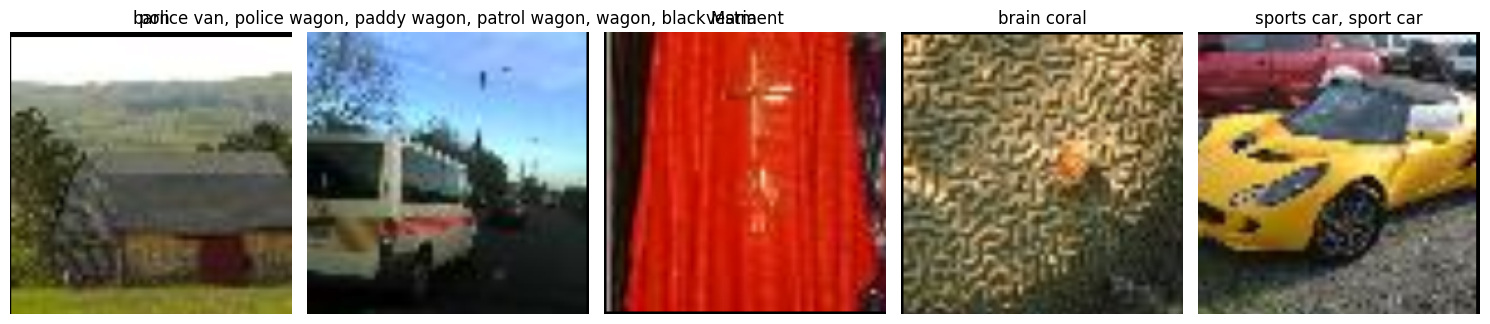

In [18]:
class_names = train_dataset.classes
class_names = [
    wnid_to_name[wnid]
    for wnid in train_dataset.classes
]
visualize_random_samples(
    train_loader=train_loader,
    class_names=class_names
)

---

#### Experiment Tracking

In [19]:
import wandb

def initialize_wandb(device):
    wandb.init(
        project="vgg19-from-scratch",
        name="vgg19_tinyimagenet_adamw_original_init",
        tags=[
            "vgg19",
            "tiny-imagenet",
            "from-scratch",
            "paper-reproduction"
        ],

        config={
            # Dataset
            "dataset": "TinyImageNet",
            "num_classes": config["n_classes"],
            "image_size": config["img_size"],

            # Architecture
            "architecture": "VGG19",
            "conv_layers": 16,
            "maxpool_layers": 5,
            "fc_layers": 3,

            # Parameters
            "feature_params": feature_params,
            "classifier_params": classifier_params,
            "total_params": total_params,

            # Training
            "epochs": config["epochs"],
            "batch_size": config["batch_size"],

            # Optimizer
            "optimizer": config["optimizer"],
            "learning_rate": config["lr"],
            "momentum": config["momentum"],
            "weight_decay": config["weight_decay"],

            # Initialization
            "weight_init": "Normal(0, 0.01)",
            "bias_init": "Zero",

            # Loss
            "loss_fn": "CrossEntropyLoss",

            # Hardware
            "device": str(device)
        }
    )

---

In [20]:
def get_accuracy(logits, target):
    y_preds = torch.argmax(logits, dim = -1)
    acc = (y_preds == target).sum() / target.shape[0]
    return acc

#### Training Script

In [21]:
def train_model(model, optimizer, loader, device):
    wandb.watch(
        model,
        log="all",
        log_freq=100
    )
    initialize_wandb(device)
    model = model.to(device)

In [22]:
from pathlib import Path

import torch
import torch.nn as nn
import wandb

from tqdm.auto import tqdm


def train_model(
    model,
    optimizer,
    scheduler,
    train_loader,
    val_loader,
    device,
    resume: bool = True
):
    """
    Trains VGG19 on Tiny ImageNet with:

    - AMP Mixed Precision
    - WandB Logging
    - Early Stopping
    - Resume Training
    - Best Model Checkpointing
    - Periodic Checkpointing
    """

    initialize_wandb(device)

    model = model.to(device)

    wandb.watch(
        model,
        log="all",
        log_freq=100
    )

    print(f"Traing the Model on device = [{device}]")

    scaler = torch.amp.GradScaler()

    loss_fn = nn.CrossEntropyLoss()

    checkpoint_dir = Path("checkpoints")
    checkpoint_dir.mkdir(exist_ok=True)

    latest_checkpoint_path = checkpoint_dir / "latest_checkpoint.pth"
    best_checkpoint_path = checkpoint_dir / "best_model.pth"

    start_epoch = 0
    best_val_loss = float("inf")
    patience_counter = 0

    # Resume Training
    if resume and latest_checkpoint_path.exists():

        print(
            f"\nLoading Checkpoint: {latest_checkpoint_path}\n"
        )
        
        model, optimizer, scheduler, start_epoch, best_val_loss, _ = load_checkpoint(
            filepath="checkpoints/latest_checkpoint.pth",
            model=model,
            optimizer=optimizer,
            scheduler=scheduler,
            device=device
        )

        start_epoch += 1

        print(
            f"Resumed from Epoch = {start_epoch}"
        )

    # Epoch Loop
    for epoch in range(start_epoch, config["epochs"]):

        model.train()

        running_loss = 0.0
        running_correct = 0
        running_samples = 0

        train_bar = tqdm(
            train_loader,
            desc=f"Epoch [{epoch+1}/{config['epochs']}]",
            leave=False
        )

        for images, labels in train_bar:

            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            with torch.autocast(device_type = device.type):
                logits = model(images)

                loss = loss_fn(
                    logits,
                    labels
                )

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            preds = torch.argmax(
                logits,
                dim=-1
            )

            correct = (
                preds == labels
            ).sum().item()

            batch_acc = correct / labels.size(0)

            running_correct += correct
            running_samples += labels.size(0)

            running_loss += (
                loss.item() * labels.size(0)
            )
            preview_size = min(5, labels.size(0))
            preview = [
                f"{p}->{t}{'  [CORRECT]' if p == t else '  [INCORRECT]'}"
                for p, t in zip(
                    preds[:preview_size].cpu().tolist(),
                    labels[:preview_size].cpu().tolist()
                )
            ]

            train_bar.set_postfix(
                loss=f"{loss.item():.3f}",
                acc=f"{batch_acc*100:.1f}%",
                preds=" | ".join(preview)
            )

        train_loss = running_loss / running_samples
        train_acc = running_correct / running_samples

        # Validation
        model.eval()

        val_loss = 0.0
        val_correct = 0
        val_samples = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)
                with torch.autocast(device_type=device.type):
                    logits = model(images)
                    loss = loss_fn(
                        logits,
                        labels
                    )
                preds = torch.argmax(
                    logits,
                    dim=-1
                )
                val_correct += (
                    preds == labels
                ).sum().item()
                val_samples += labels.size(0)
                val_loss += (
                    loss.item() * labels.size(0)
                )

        val_loss /= val_samples
        val_acc = val_correct / val_samples
        scheduler.step(val_loss)

        # Terminal Logging
        print(
            f"\nEpoch [{epoch+1}/{config['epochs']}]"
            f" | Train Loss = {train_loss:.4f}"
            f" | Train Acc = {train_acc*100:.2f}%"
            f" | Val Loss = {val_loss:.4f}"
            f" | Val Acc = {val_acc*100:.2f}%"
        )

        # WandB Logging
        wandb.log(
            {
                "train_loss": train_loss,
                "train_acc": train_acc,
                "val_loss": val_loss,
                "val_acc": val_acc,
                "epoch": epoch + 1,
                "learning_rate": optimizer.param_groups[0]["lr"]
            }
        )

        # Save Latest Checkpoint
        save_checkpoint(
            model=model,
            optimizer=optimizer,
            scheduler = scheduler,
            epoch=epoch,
            loss=val_loss,
            filepath=str(latest_checkpoint_path)
        )

        # Save Best Model
        if val_loss < best_val_loss:
            print(
                f"Validation Loss Improved "
                f"({best_val_loss:.4f} -> {val_loss:.4f})"
            )

            best_val_loss = val_loss
            patience_counter = 0
            save_checkpoint(
                model=model,
                optimizer=optimizer,
                scheduler = scheduler,
                epoch=epoch,
                loss=val_loss,
                filepath=str(best_checkpoint_path)
            )

        else:
            patience_counter += 1

        # Periodic Checkpoints
        if (epoch + 1) % 5 == 0:
            save_checkpoint(
                model=model,
                optimizer=optimizer,
                scheduler = scheduler,
                epoch=epoch,
                loss=val_loss,
                filepath=str(
                    checkpoint_dir /
                    f"epoch_{epoch+1:03d}.pth"
                )
            )

        # Early Stopping
        if patience_counter >= 10:
            print(
                "\nEarly Stopping Triggered\n"
            )
            break

    print(
        "\nTraining Completed Successfully.\n"
    )

    return model, best_val_loss


---

### Getting the Model ready for Training

In [23]:
model = VGG19(
    in_channels = config["in_channels"]
)
optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.001,
    momentum=0.9,
    weight_decay=config["weight_decay"]
)
# Accordingly to the paper: The learning rate was initially set to 1e−2, and then decreased by a factor of 10 when the validation
# set accuracy stopped improving. In total, the learning rate was decreased 3 times
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.1,
    patience=3
)

#### Overfitting the Model on batch_size = 10

In [24]:
def overfit(overfit_epoch: int, overfit_batch_size: int = 2):
    model = VGG19(
        in_channels = config["in_channels"]
    )
    overfit_lr = 0.0001
    overfit_momemtum = 0.9
    optimizer = torch.optim.SGD(
        model.parameters(),
        lr= overfit_lr,
        momentum = overfit_momemtum
    )
    
    img_overfit = images[:overfit_batch_size]
    labels_overfit = labels[:overfit_batch_size]
    loss_fn = nn.CrossEntropyLoss()

    print(f"Overfitting the Model on Batch Size = {overfit_batch_size} | Epochs = {overfit_epoch}")
    preds = model(img_overfit).argmax(-1)
    print(f"Initial Predictions: {preds}")
    print(f"Original Labels: {labels_overfit}")
    model.train()
    for epoch in range(overfit_epoch):
        logits = model(img_overfit)
        loss = loss_fn(
            logits,
            labels_overfit
        )

        acc = get_accuracy(logits, labels_overfit)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if epoch % 2 == 0:
            print(f"Epoch [{epoch}/{overfit_epoch}] | Loss = {loss:.3f} | Accuracy = {acc * 100}%")
            if acc.item() >= 0.999:
                print("\n-------------------------------------- Overfitting Sucessfull -------------------------------------- \n")
                print(f"Details:")
                print(f"> Exiting at Epochs: {epoch}")
                print(f"> lr = {overfit_lr}")
                print(" > Forward pass works")
                print(" > Backward pass works")
                print(" > Labels are correct")
                print(" > Optimizer works")
                print(" > Architecture is trainable")
                print(f"\nPredictions = {logits.argmax(-1)} | Original Labels: {labels_overfit}\n")
                break
    return model
# overfitted_model = overfit(overfit_epoch = 100, overfit_batch_size = 10)

In [25]:
# Using BatchNorm + SGD (lr = 0.001, momentum = 0.9)

# Overfitting the Model on Batch Size = 10 | Epochs = 100

# Initial Predictions: tensor([ 50,  50,  27, 194,  26,  50,  18,  50,  50, 182])

# Original Labels: tensor([ 59, 100,  43, 167,  13,  58, 130, 117, 116, 150])

# Epoch [0/100] | Loss = 6.528 | Accuracy = 0.0%

# Epoch [2/100] | Loss = 1.629 | Accuracy = 40.0%

# Epoch [4/100] | Loss = 0.652 | Accuracy = 70.0%

# Epoch [6/100] | Loss = 0.278 | Accuracy = 90.0%

# Epoch [8/100] | Loss = 0.073 | Accuracy = 100.0%



# -------------------------------------- Overfitting Sucessfull -------------------------------------- 



# Details:

# > Exiting at Epochs: 8

# > lr = 0.001

#  > Forward pass works

#  > Backward pass works

#  > Labels are correct

#  > Optimizer works

#  > Architecture is trainable



# Predictions = tensor([ 59, 100,  43, 167,  13,  58, 130, 117, 116, 150]) | Original Labels: tensor([ 59, 100,  43, 167,  13,  58, 130, 117, 116, 150])


# Not using BatchNorm + SGD (lr = 0.001; momentum = 0.9)
# Overfitting the Model on Batch Size = 10 | Epochs = 100
# Initial Predictions: tensor([109, 109, 109, 133, 109, 109, 109, 109, 109, 109])
# Original Labels: tensor([189,  48, 150,  72, 173, 199,  67, 198, 182,  52])
# Epoch [0/100] | Loss = 5.321 | Accuracy = 0.0%
# Epoch [2/100] | Loss = 5.139 | Accuracy = 10.0%
# ..
# ..
# ..
# Epoch [82/100] | Loss = 0.813 | Accuracy = 90.0%
# Epoch [84/100] | Loss = 0.660 | Accuracy = 90.0%
# Epoch [86/100] | Loss = 0.490 | Accuracy = 90.0%
# Epoch [88/100] | Loss = 0.273 | Accuracy = 90.0%
# Epoch [90/100] | Loss = 0.029 | Accuracy = 100.0%

# -------------------------------------- Overfitting Sucessfull -------------------------------------- 

# Details:
# > Exiting at Epochs: 90
# > lr = 0.001
#  > Forward pass works
#  > Backward pass works
#  > Labels are correct
#  > Optimizer works
#  > Architecture is trainable

# Predictions = tensor([189,  48, 150,  72, 173, 199,  67, 198, 182,  52]) | Original Labels: tensor([189,  48, 150,  72, 173, 199,  67, 198, 182,  52])


# Not Using BatchNorm Optimizer = SGD (lr = 0.0001), momentum = 0.9
# Overfitting the Model on Batch Size = 10 | Epochs = 100
# Initial Predictions: tensor([149, 149,  72, 149, 149, 149, 149, 149, 149, 149])
# Original Labels: tensor([ 88, 112, 130, 132,  89,   0, 170,  24,  80,  31])
# Epoch [0/100] | Loss = 5.315 | Accuracy = 0.0%
# Epoch [2/100] | Loss = 5.293 | Accuracy = 0.0%
# Epoch [4/100] | Loss = 5.250 | Accuracy = 0.0%
# Epoch [6/100] | Loss = 5.194 | Accuracy = 0.0%
# Epoch [8/100] | Loss = 5.129 | Accuracy = 10.0%
# Epoch [10/100] | Loss = 5.058 | Accuracy = 10.0%
# Epoch [12/100] | Loss = 4.979 | Accuracy = 10.0%
# Epoch [14/100] | Loss = 4.889 | Accuracy = 20.0%
# Epoch [16/100] | Loss = 4.786 | Accuracy = 20.0%
# Epoch [18/100] | Loss = 4.663 | Accuracy = 20.0%
# Epoch [20/100] | Loss = 4.515 | Accuracy = 20.0%
# Epoch [22/100] | Loss = 4.328 | Accuracy = 20.0%
# Epoch [24/100] | Loss = 4.084 | Accuracy = 20.0%
# Epoch [26/100] | Loss = 3.758 | Accuracy = 20.0%
# Epoch [28/100] | Loss = 3.324 | Accuracy = 10.0%
# Epoch [30/100] | Loss = 2.798 | Accuracy = 10.0%
# Epoch [32/100] | Loss = 2.280 | Accuracy = 10.0%
# Epoch [34/100] | Loss = 1.800 | Accuracy = 60.000003814697266%
# Epoch [36/100] | Loss = 1.412 | Accuracy = 90.0%
# Epoch [38/100] | Loss = 1.118 | Accuracy = 80.0%
# Epoch [40/100] | Loss = 0.722 | Accuracy = 100.0%

# -------------------------------------- Overfitting Sucessfull -------------------------------------- 

# Details:
# > Exiting at Epochs: 40
# > lr = 0.0001
#  > Forward pass works
#  > Backward pass works
#  > Labels are correct
#  > Optimizer works
#  > Architecture is trainable

# Predictions = tensor([ 88, 112, 130, 132,  89,   0, 170,  24,  80,  31]) | Original Labels: tensor([ 88, 112, 130, 132,  89,   0, 170,  24,  80,  31])



#### Train the Model

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model, best_val_loss = train_model(
    model = model,
    optimizer = optimizer,
    scheduler = scheduler,
    train_loader = train_loader,
    val_loader = val_loader,
    device = device,
    resume = True
)

epoch,▁▂▃▃▄▅▆▆▇█
learning_rate,█▂▂▂▂▁▁▁▁▁
train_acc,▁▃▆▇▇▇██▇█
train_loss,█▆▃▂▂▂▁▁▁▁
val_acc,▁▁█▅▇█▇▇▇▅
val_loss,█▅▂▄▁▃▅▁▃▄
epoch,46
learning_rate,0.0
train_acc,0.79641
train_loss,0.72061
val_acc,0.593


Traing the Model on device = [cuda]

Loading Checkpoint: checkpoints\latest_checkpoint.pth



C:\Users\Himanshu Singh\AppData\Local\Temp\ipykernel_24004\3331575776.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(


Resumed from Epoch = 46


Epoch [47/200]:   0%|          | 0/4167 [00:00<?, ?it/s]

## Training Environment

The VGG19-BatchNorm model was trained from scratch on an RTX 3050 Laptop GPU (6 GB VRAM).

### Hardware

* GPU: NVIDIA RTX 3050 Laptop GPU (6 GB VRAM)
* CUDA Version: 13.1
* Driver Version: 592.27
* RAM: 16 GB

### Resource Utilization

During training, the GPU remained fully utilized for extended periods:

| Metric          | Value         |
| --------------- | ------------- |
| GPU Utilization | ~100%         |
| VRAM Usage      | ~5.1 / 6.0 GB |
| GPU Temperature | ~86°C         |
| Power Draw      | ~57 W         |

The model trained continuously for more than 10 hours while maintaining stable utilization and memory consumption. The sustained 100% GPU utilization indicates that the training pipeline was able to keep the GPU busy without significant data-loading bottlenecks.

### Notes

Training deep convolutional networks such as VGG19 from scratch is computationally expensive. Even on modern consumer hardware, a single experiment can take many hours, making checkpointing, early stopping, and training monitoring essential components of the workflow.


#### Save the Trained Model

In [28]:
save_checkpoint(
    model=model,
    optimizer=optimizer,
    scheduler = scheduler,
    epoch=config["epochs"],
    loss = best_val_loss,
    filepath = "final_model.pth"
)

#### Load the Trained Model

In [29]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model, _, _, _, _, config = load_checkpoint(
    filepath="checkpoints/best_model.pth",
    model=model,
    optimizer=None,
    scheduler=None,
    device=device
)
model.eval()

C:\Users\Himanshu Singh\AppData\Local\Temp\ipykernel_24004\3331575776.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(


VGG19(
  (features): ConvNets(
    (vgg_19_layers): Sequential(
      (0): Sequential(
        (0): VGGBlock(
          (conv_1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (batch_norm_1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (batch_norm_2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU()
          (conv_2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (block): Sequential(
            (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): ReLU()
            (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (5): ReLU()
          )
        )
        (1): MaxPool2d

#### Prediction from Loaded Model

In [30]:
loss_fn = nn.CrossEntropyLoss()
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        with torch.autocast(device_type=device.type):
            logits = model(images)
            loss = loss_fn(
                logits,
                labels
            )
        preds = torch.argmax(
            logits,
            dim=-1
        )

In [35]:
from PIL import Image
import torch


def predict_image(
    image_path,
    model,
    transform,
    idx_to_class_name,
    device
):
    model.eval()

    image = Image.open(
        image_path
    ).convert("RGB")

    image = transform(image)

    image = image.unsqueeze(0)

    image = image.to(device)

    with torch.no_grad():
        logits = model(image)

        pred_idx = torch.argmax(
            logits,
            dim=-1
        ).item()

    return idx_to_class_name[pred_idx]

In [39]:
predict_image(
    image_path="../data/tiny-imagenet-200/test/images/test_9.JPEG",
    model=model,
    transform=val_transform,
    idx_to_class_name=class_names,
    device=device
)

'neck brace'

In [47]:
import random
from pathlib import Path

import torch
import matplotlib.pyplot as plt
from torchvision import transforms
from PIL import Image


def visualize_predictions(
    test_dir,
    model,
    transform,
    idx_to_class_name,
    device,
    n_samples=5
):
    model.eval()

    image_paths = list(
        Path(test_dir).glob("*.JPEG")
    )

    selected = random.sample(
        image_paths,
        n_samples
    )

    display_transform = transforms.Resize(
        (1024, 1024)
    )

    fig, axes = plt.subplots(
        1,
        n_samples,
        figsize=(18, 5)
    )

    if n_samples == 1:
        axes = [axes]

    with torch.no_grad():

        for ax, image_path in zip(
            axes,
            selected
        ):

            pil_image = Image.open(
                image_path
            ).convert("RGB")

            # For model inference
            x = transform(
                pil_image
            )

            logits = model(
                x.unsqueeze(0).to(device)
            )

            pred = torch.argmax(
                logits,
                dim=-1
            ).item()

            confidence = (
                torch.softmax(
                    logits,
                    dim=-1
                )[0, pred]
                .item()
            )

            # For visualization only
            display_image = display_transform(
                pil_image
            )

            ax.imshow(display_image)

            ax.set_title(
                f"{idx_to_class_name[pred][:25]}\n"
                f"{confidence:.2%}"
            )

            ax.axis("off")

    plt.tight_layout()
    plt.show()

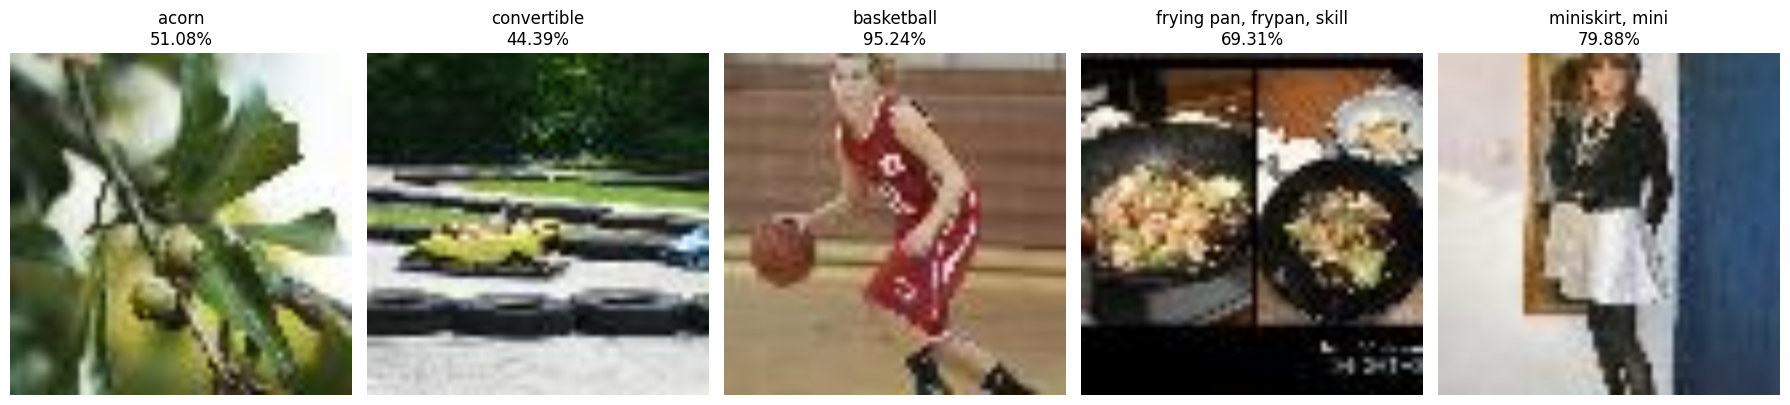

In [52]:
visualize_predictions(
    test_dir="../data/tiny-imagenet-200/test/images",
    model=model,
    transform=val_transform,
    idx_to_class_name=class_names,
    device=device
)